# Evaluating conventional CNN vs a pre-trained CNN for image recognition

## Explore datasets

In [1]:
# Images are downloaded from Kaggle CLI.
from pathlib import Path

base_dir : str = "chest_xray/chest_xray/"

train_normal_dir : str = base_dir+"train/NORMAL/"
test_normal_dir : str = base_dir+"test/NORMAL/"
val_normal_dir : str = base_dir+"val/NORMAL/"
train_pneumonia_dir : str = base_dir+"train/PNEUMONIA/"
test_pneumonia_dir : str = base_dir+"test/PNEUMONIA/"
val_pneumonia_dir : str = base_dir+"val/PNEUMONIA/"

train_pn_files_count : int =  sum(1 for item in Path(train_pneumonia_dir).rglob("*.jpeg") if item.is_file())
test_pn_files_count : int = sum(1 for item in Path(test_pneumonia_dir).rglob("*.jpeg") if item.is_file())
train_nrm_files_count : int = sum(1 for item in Path(train_normal_dir).rglob("*.jpeg") if item.is_file())
test_nrm_files_count : int = sum(1 for item in Path(test_normal_dir).rglob("*.jpeg") if item.is_file())
val_nrm_files_count : int = sum(1 for item in Path(val_normal_dir).rglob("*.jpeg") if item.is_file())
val_pn_files_count : int = sum(1 for item in Path(val_pneumonia_dir).rglob("*.jpeg") if item.is_file())

print(f"Total number of training PNEUMONIA files: {train_pn_files_count}")
print(f"Total number of testing PNEUMONIA files: {test_pn_files_count}")
print(f"Total number of validation PNEUMONIA files: {val_pn_files_count}")
print(f"Total number of training NORMAL files: {train_nrm_files_count}")
print(f"Total number of testing NORMAL files: {test_nrm_files_count}")
print(f"Total number of validation NORMAL files: {val_nrm_files_count}")
print(20*"-")
print(f"Total PNEUMONIA files: {train_pn_files_count + test_pn_files_count + val_pn_files_count}")
print(f"Total NORMAL files: {train_nrm_files_count + test_nrm_files_count + val_nrm_files_count}")
print(20*"-")
print(f"Total Images: {train_pn_files_count + test_pn_files_count + val_pn_files_count + train_nrm_files_count + test_nrm_files_count + val_nrm_files_count}")


Total number of training PNEUMONIA files: 3875
Total number of testing PNEUMONIA files: 390
Total number of validation PNEUMONIA files: 8
Total number of training NORMAL files: 1341
Total number of testing NORMAL files: 234
Total number of validation NORMAL files: 8
--------------------
Total PNEUMONIA files: 4273
Total NORMAL files: 1583
--------------------
Total Images: 5856


## Split Datasets into Train, Test, and Validation

In [2]:
# Split dataset to 80:15:5
pneumonia_folders : list[str] = [train_pneumonia_dir, test_pneumonia_dir, val_pneumonia_dir]
pneumonia_images : list[str] = [
    str(filepath) for folder_path in pneumonia_folders for filepath in Path(folder_path).rglob("*.jpeg")
]

normal_folders : list[str] = [train_normal_dir, test_normal_dir, val_normal_dir]
normal_images : list[str] = [
    str(filepath) for folder_path in normal_folders for filepath in Path(folder_path).rglob("*.jpeg")
]

print(f"Pneumonia images: {len(pneumonia_images)}")
print(f"Normal images: {len(normal_images)}")

Pneumonia images: 4273
Normal images: 1583


In [3]:
from sklearn.model_selection import train_test_split
# 0 for normal, 1 for pneumonia
all_images = normal_images + pneumonia_images
all_labels = [0] * len(normal_images) + [1] * len(pneumonia_images)

# First split: 80% train, 20% temp (test + val)
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, 
    all_labels, 
    test_size=0.20, 
    random_state=42, 
    stratify=all_labels
)

# Second split: Split the 20% temp into 15% test and 5% val (75% / 25% of temp)
test_imgs, val_imgs, test_labels, val_labels = train_test_split(
    temp_imgs, 
    temp_labels, 
    test_size=0.25,
    random_state=42, 
    stratify=temp_labels
)

print(f"Train set: {len(train_imgs)} images | Normal: {train_labels.count(0)} ({train_labels.count(0)/len(train_imgs):.1%}), Pneumonia: {train_labels.count(1)} ({train_labels.count(1)/len(train_imgs):.1%})")
print(f"Test set:  {len(test_imgs)} images | Normal: {test_labels.count(0)} ({test_labels.count(0)/len(test_imgs):.1%}), Pneumonia: {test_labels.count(1)} ({test_labels.count(1)/len(test_imgs):.1%})")
print(f"Val set:   {len(val_imgs)} images | Normal: {val_labels.count(0)} ({val_labels.count(0)/len(val_imgs):.1%}), Pneumonia: {val_labels.count(1)} ({val_labels.count(1)/len(val_imgs):.1%})")


Train set: 4684 images | Normal: 1266 (27.0%), Pneumonia: 3418 (73.0%)
Test set:  879 images | Normal: 238 (27.1%), Pneumonia: 641 (72.9%)
Val set:   293 images | Normal: 79 (27.0%), Pneumonia: 214 (73.0%)


## Model Building

In [4]:
from keras import layers
from keras import models

img_size = 224

model = models.Sequential([
    # Input layer matching the preprocessed image size (224, 224, 3)
    layers.Input(shape=(img_size, img_size, 3)),
    
    # Modern Keras 3 Data Augmentation (only active during training)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=7 / 360), # 7 degrees rotation
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(height_factor=0.45, width_factor=0.45),
    
    # Block 1: Focuses on low-level features (edges, lines)
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(), # Stabilizes training and speeds up convergence
    layers.MaxPooling2D((2, 2)),  # Downsamples spatial dimensions (224x224 -> 112x112)
    
    # Block 2: Focuses on mid-level features (shapes, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # 112x112 -> 56x56
    
    # Block 3: Focuses on complex high-level structures
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # 56x56 -> 28x28
    
    # Block 4: Deep abstract representations
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # 28x28 -> 14x14
    
    # Flattening layer: Conveys the 3D feature maps into a 1D vector
    layers.Flatten(),
    
    # Fully Connected (Dense) Block
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization layer to prevent overfitting
    
    # Output Layer: 1 node with sigmoid activation for binary classification (0 vs 1)
    layers.Dense(1, activation='sigmoid')
])

# Compile model with standard Adam optimizer and binary crossentropy loss
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', 'mae']
)

# Inspect the network structure
model.summary(print_fn=print)


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼─────────────────────

In [5]:
import cv2
import numpy as np

def load_and_preprocess(image_paths, labels, target_size=(224, 224)):
    X = []
    y = []
    for path, label in zip(image_paths, labels):
        try:
            # Read image as grayscale to match original workflow, then convert to RGB
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)
            img = np.dstack([img, img, img])
            img = img.astype(np.float32) / 255.0
            
            X.append(img)
            y.append(label)
        except Exception:
            continue
    return np.array(X), np.array(y)

print("Loading and preprocessing training images...")
X_train, y_train = load_and_preprocess(train_imgs, train_labels)

print("Loading and preprocessing validation images...")
X_val, y_val = load_and_preprocess(val_imgs, val_labels)

print(f"Loaded {len(X_train)} training images and {len(X_val)} validation images.")


Loading and preprocessing training images...
Loading and preprocessing validation images...
Loaded 4684 training images and 293 validation images.


In [6]:
from sklearn.utils import class_weight
import numpy as np

batch_size = 32

# Calculate Class Weights for imbalance (0: Normal, 1: Pneumonia)
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print(f"Class weights: {class_weights}")


Class weights: {0: np.float64(1.8499210110584519), 1: np.float64(0.6851960210649503)}


In [7]:
epochs = 15

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)


Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 38s 249ms/step - binary_accuracy: 0.7596 - loss: 0.8087 - mae: 0.2786 - val_binary_accuracy: 0.7304 - val_loss: 30.3388 - val_mae: 0.2696
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 250ms/step - binary_accuracy: 0.8034 - loss: 0.4024 - mae: 0.2385 - val_binary_accuracy: 0.7304 - val_loss: 5.1535 - val_mae: 0.2694
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 251ms/step - binary_accuracy: 0.8375 - loss: 0.3601 - mae: 0.2115 - val_binary_accuracy: 0.8737 - val_loss: 0.3233 - val_mae: 0.2131
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 36s 247ms/step - binary_accuracy: 0.8456 - loss: 0.3460 - mae: 0.1987 - val_binary_accuracy: 0.2867 - val_loss: 2.6140 - val_mae: 0.6273
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 37s 250ms/step - binary_accuracy: 0.8591 - loss: 0.3381 - mae: 0.1973 - val_binary_accuracy: 0.8089 - val_loss: 0.4200 - val_mae: 0.3078
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 36s 246ms/step - binary_accuracy: 0.8533 - loss: 0.3327 - mae: 0.1978 - va

## Model Building - 

In [8]:
X_test, y_test = load_and_preprocess(test_imgs, test_labels)
print(f"Loaded {len(X_test)} test images.")


Loaded 879 test images.


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
================ EVALUATION METRICS ================
Accuracy:  0.9261 (92.61%)
Precision: 0.9364 (93.64%)
Recall:    0.9641 (96.41%)
F1 Score:  0.9500 (95.00%)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.82      0.86       238
   Pneumonia       0.94      0.96      0.95       641

    accuracy                           0.93       879
   macro avg       0.92      0.89      0.90       879
weighted avg       0.93      0.93      0.93       879



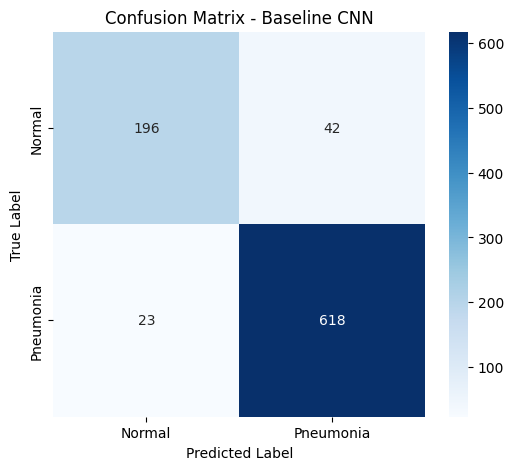

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions (probabilities)
predictions_prob = model.predict(X_test)

# 2. Convert probabilities to binary class labels (using standard 0.5 threshold)
predictions_class = (predictions_prob > 0.5).astype(int)

# 3. Calculate evaluation metrics
accuracy = accuracy_score(y_test, predictions_class)
precision = precision_score(y_test, predictions_class)
recall = recall_score(y_test, predictions_class)
f1 = f1_score(y_test, predictions_class)

print("================ EVALUATION METRICS ================")
print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1 Score:  {f1:.4f} ({f1 * 100:.2f}%)")
print("====================================================")

# 4. Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, predictions_class, target_names=["Normal", "Pneumonia"]))

# 5. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, predictions_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Normal", "Pneumonia"], 
            yticklabels=["Normal", "Pneumonia"])
plt.title("Confusion Matrix - Baseline CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Pre-trained CNN (Transfer Learning with DenseNet121)

We will now load a pre-trained **DenseNet121** network (trained on ImageNet). We freeze its convolutional layers to retain the general features it has learned, and add our own binary classifier on top.

In [10]:
import keras
from keras import layers
from keras import models

print("Initializing pre-trained DenseNet121 base...")
# 1. Load the pre-trained DenseNet121 base
base_model = keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Freeze the base layers so we don't destroy their pre-trained features
base_model.trainable = False

# 3. Add custom classification head on top
model_pretrained = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary classification output
])

# 4. Compile the model with identical parameters for fair comparison
model_pretrained.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', 'mae']
)

print("Pre-trained DenseNet121 model built and compiled successfully.")
model_pretrained.summary(print_fn=print)


Initializing pre-trained DenseNet121 base...
Pre-trained DenseNet121 model built and compiled successfully.


Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)         

In [11]:
# Train the pre-trained model for 15 epochs
epochs = 15

print("Starting training of pre-trained model...")
history_pretrained = model_pretrained.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)
print("Pre-trained model training completed.")


Starting training of pre-trained model...
Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 84s 541ms/step - binary_accuracy: 0.8725 - loss: 0.2943 - mae: 0.1861 - val_binary_accuracy: 0.9181 - val_loss: 0.1818 - val_mae: 0.1189
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - binary_accuracy: 0.9195 - loss: 0.2018 - mae: 0.1199 - val_binary_accuracy: 0.9454 - val_loss: 0.1384 - val_mae: 0.1025
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 122s 830ms/step - binary_accuracy: 0.9306 - loss: 0.1709 - mae: 0.1029 - val_binary_accuracy: 0.9454 - val_loss: 0.1371 - val_mae: 0.0914
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 83s 563ms/step - binary_accuracy: 0.9368 - loss: 0.1575 - mae: 0.0939 - val_binary_accuracy: 0.9659 - val_loss: 0.1012 - val_mae: 0.0707
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 81s 554ms/step - binary_accuracy: 0.9436 - loss: 0.1540 - mae: 0.0903 - val_binary_accuracy: 0.9556 - val_loss: 0.1220 - val_mae: 0.0797
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 78s 534ms/step - binary_accuracy: 

28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 520ms/step
================ PRE-TRAINED MODEL EVALUATION ================
Accuracy:  0.9568 (95.68%)
Precision: 0.9871 (98.71%)
Recall:    0.9532 (95.32%)
F1 Score:  0.9698 (96.98%)

Classification Report (DenseNet121):
              precision    recall  f1-score   support

      Normal       0.88      0.97      0.92       238
   Pneumonia       0.99      0.95      0.97       641

    accuracy                           0.96       879
   macro avg       0.94      0.96      0.95       879
weighted avg       0.96      0.96      0.96       879



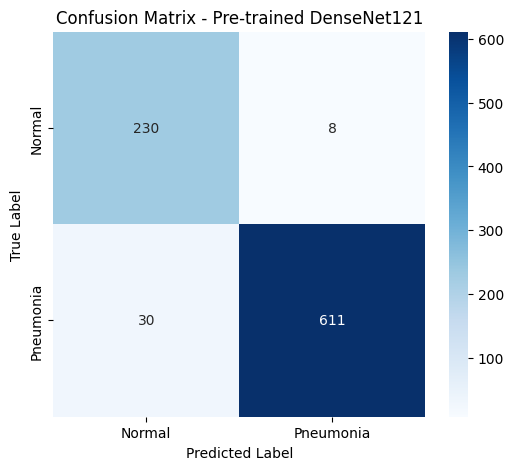

In [12]:
# Generate predictions and calculate metrics for pre-trained model
preds_pretrained_prob = model_pretrained.predict(X_test)
preds_pretrained_class = (preds_pretrained_prob > 0.5).astype(int)

acc_pt = accuracy_score(y_test, preds_pretrained_class)
prec_pt = precision_score(y_test, preds_pretrained_class)
rec_pt = recall_score(y_test, preds_pretrained_class)
f1_pt = f1_score(y_test, preds_pretrained_class)

print("================ PRE-TRAINED MODEL EVALUATION ================")
print(f"Accuracy:  {acc_pt:.4f} ({acc_pt * 100:.2f}%)")
print(f"Precision: {prec_pt:.4f} ({prec_pt * 100:.2f}%)")
print(f"Recall:    {rec_pt:.4f} ({rec_pt * 100:.2f}%)")
print(f"F1 Score:  {f1_pt:.4f} ({f1_pt * 100:.2f}%)")
print("==============================================================")

print("\nClassification Report (DenseNet121):")
print(classification_report(y_test, preds_pretrained_class, target_names=["Normal", "Pneumonia"]))

cm_pt = confusion_matrix(y_test, preds_pretrained_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pt, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Normal", "Pneumonia"], 
            yticklabels=["Normal", "Pneumonia"])
plt.title("Confusion Matrix - Pre-trained DenseNet121")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Model Comparison

We will now plot the learning curves of both models side-by-side to analyze training and validation behaviors.

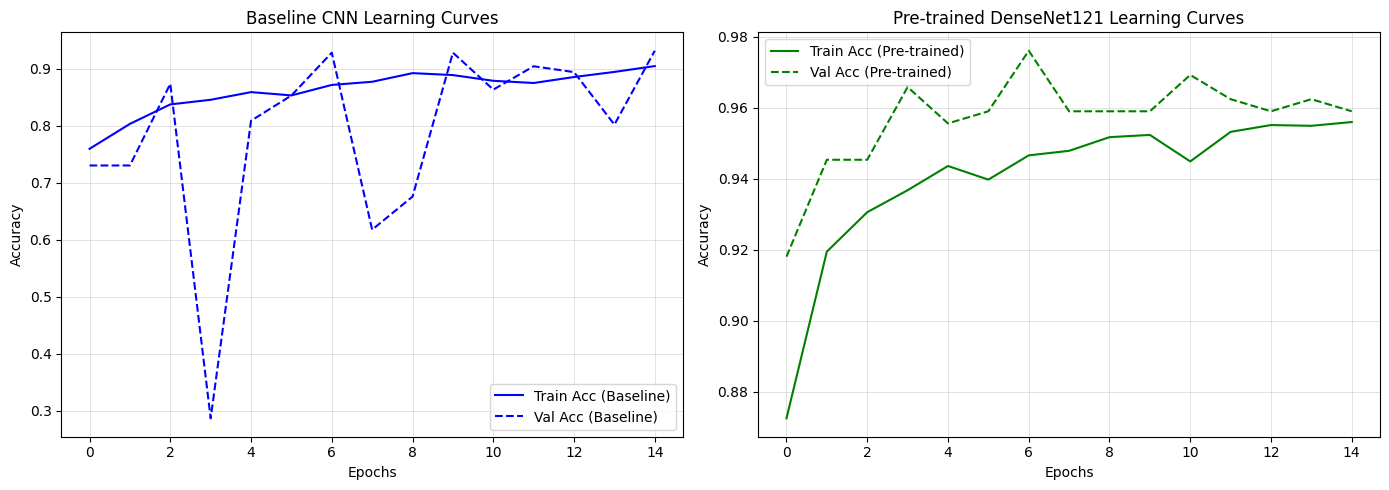

In [13]:
# Plot side-by-side comparison of training/validation curves
plt.figure(figsize=(14, 5))

# 1. Baseline CNN Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['binary_accuracy'], 'b-', label='Train Acc (Baseline)')
plt.plot(history.history['val_binary_accuracy'], 'b--', label='Val Acc (Baseline)')
plt.title('Baseline CNN Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Pre-trained DenseNet121 Curves
plt.subplot(1, 2, 2)
plt.plot(history_pretrained.history['binary_accuracy'], 'g-', label='Train Acc (Pre-trained)')
plt.plot(history_pretrained.history['val_binary_accuracy'], 'g--', label='Val Acc (Pre-trained)')
plt.title('Pre-trained DenseNet121 Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
